In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io
from skimage.filters import threshold_mean
import scipy.stats
import dabest
import os

import sys
sys.path.append('../')
from src.functions import get_parameters

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|███████████████████████████████████████████████████████| 11/11 [00:01<00:00, 10.86it/s]


Numba compilation complete!


In [13]:
parameter_local_path = '../conf/local/parameters.yml'

parameters = get_parameters(parameter_local_path)

base_folder = parameters["data_dir"]
out_folder = parameters["out_dir"]



Parameters: 
{'key_file': 'T:/Olya/Experiments/migration_assay/in_vivo/mosaic_EC/2024-07-22_keyfile.xlsx', 'data_dir': 'T:/Olya/Experiments/migration_assay/in_vivo/mosaic_EC/new_analysis/', 'out_dir': 'T:/Olya/Experiments/migration_assay/in_vivo/mosaic_EC/new_analysis/output_notebook_2025/', 'experiment_IDs_exclude': [], 'pixel_no_per_retina': 10000, 'image_types': ['GFP'], 'load_conditions': ['CDH5CreERT2 mTmG', 'CDH5CreERT2 SMAD4 mTmG', 'CDH5CreERT2 Alk1 mTmG'], 'plot_kde': False, 'plot_individual_hist': False, 'plot_cond_kde': True, 'radial_bins': [[0, 1200]], 'time_points': ['P5_P8', 'P5_P15'], 'number_ks_test': 1}


In [14]:
px_per_cell = 300.0

# 1) Single source of truth
base_colors = {
    "ctrl":    "#000000",
    "Smad4 KO":"#0D79F2",
    "Alk1 KO": "#C333CC",
}

# 2) Build derived palettes programmatically
timepoints = ["P8", "P15"]

condition_palette = base_colors.copy()

time_condition_palette = {
    f"{cond} {tp}": base_colors[cond]
    for cond in ["ctrl", "Smad4 KO", "Alk1 KO"]
    for tp in timepoints
}

time_series_palette1 = {
    f"{cond} {tp} (P5)": base_colors[cond]
    for cond in ["ctrl", "Smad4 KO", "Alk1 KO"]
    for tp in timepoints
}

time_series_palette2 = {
    "P8 (inj. P5)":  "#ccbb44",
    "P15 (inj. P5)": "#4477aa",
}

# 3) Optional: validate that all hex strings are valid colors
import matplotlib.colors as mcolors
def _validate_palette(pal, name):
    for k, v in pal.items():
        try:
            mcolors.to_rgb(v)
        except ValueError as e:
            raise ValueError(f"Invalid color for '{k}' in {name}: {v}") from e

_validate_palette(condition_palette, "condition_palette")
_validate_palette(time_condition_palette, "time_condition_palette")
_validate_palette(time_series_palette1, "time_series_palette1")
_validate_palette(time_series_palette2, "time_series_palette2")

# Plot limits & effect size (your originals)
swarm_ylim = (0, 15)
contrast_ylim = (-4, 2)
effect_size = "mean_diff"


In [20]:
plot_features = pd.read_csv(os.path.join(out_folder, "plot_features.csv"))
plot_features["ExperimentID"] = plot_features["ExperimentID"].astype(int)

plot_features["time_point_num"] = (
    plot_features["time_point"].astype(str).str.extract(r"(\d+)")[0].astype(int)
)

plot_features

,ExperimentID,time_interval,time_point,condition,mean_AV,mean_R,median_AV,median_R,10th_AV,25th_AV,75th_AV,90th_AV,10th_R,25th_R,75th_R,90th_R,time_point_num
0,1,P5_P8,P8,Cdh5CreERT2;mTmG;Alk1FloxFlox,0.508319,1447.314177,0.525584,1530.245242,0.084786,0.255511,0.753628,0.889306,826.594459,1203.080015,1796.786152,1921.327876,8
1,2,P5_P8,P8,Cdh5CreERT2;mTmG;Alk1FloxFlox,0.506551,1556.923852,0.533185,1679.784554,0.174817,0.347555,0.666497,0.797154,905.359759,1352.558992,1871.124168,1994.508188,8
2,3,P5_P8,P8,Cdh5CreERT2;mTmG;Alk1FloxFlox,0.592160,1296.857121,0.692975,1364.048036,0.144130,0.328182,0.803548,0.934499,560.125640,906.107230,1692.296025,1936.808349,8
3,4,P5_P8,P8,Cdh5CreERT2;mTmG;Alk1FloxFlox,0.500680,1354.428905,0.499831,1454.999950,0.143512,0.286670,0.712902,0.861111,609.138779,994.488364,1758.152366,1896.158919,8
4,5,P5_P15,P15,Cdh5CreERT2;mTmG;Alk1FloxFlox,0.524263,1452.444342,0.572124,1516.795307,0.076723,0.279093,0.747007,0.924261,789.083453,1144.926620,1849.602040,2004.240504,15
5,6,P5_P15,P15,Cdh5CreERT2;mTmG;Alk1FloxFlox,0.572699,1428.396640,0.624356,1499.956761,0.130872,0.359211,0.776559,0.925086,743.604608,1090.377363,1827.584661,1998.846553,15
6,7,P5_P8,P8,Cdh5CreERT2;mTmG;SMAD4FloxFlox,0.365174,1424.259808,0.300146,1504.200610,0.000000,0.136263,0.589333,0.795493,774.481781,1241.283902,1738.273402,1857.579080,8
7,8,P5_P8,P8,Cdh5CreERT2;mTmG;SMAD4FloxFlox,0.521220,1475.702320,0.512736,1602.651393,0.204794,0.335329,0.720286,0.875843,866.144101,1332.573205,1755.065723,1864.952691,8
8,9,P5_P8,P8,Cdh5CreERT2;mTmG;SMAD4FloxFlox,0.525565,1584.834555,0.572406,1699.144493,0.163316,0.373562,0.700245,0.790939,870.351857,1355.203402,1943.026723,2056.251666,8
9,10,P5_P8,P8,Cdh5CreERT2;mTmG;SMAD4FloxFlox,0.505580,1464.500713,0.588227,1603.754270,0.049762,0.266427,0.720919,0.830959,740.381343,1138.930620,1833.820859,1955.197644,8


In [21]:
df["group"] = df["condition"] + "_" + df["time_point"].astype(str)
print(df["group"].unique())


['Cdh5CreERT2;mTmG;Alk1FloxFlox_P8' 'Cdh5CreERT2;mTmG;Alk1FloxFlox_P15'
 'Cdh5CreERT2;mTmG;SMAD4FloxFlox_P8' 'Cdh5CreERT2;mTmG;SMAD4FloxFlox_P15'
 'Cdh5CreERT2 mTmG_P8' 'Cdh5CreERT2 mTmG_P15']


In [25]:
# 1) Make sure we have a numeric time and a "P8"/"P15" label
plot_features["time_point_num"] = (
    plot_features["time_point"].astype(str).str.extract(r"(\d+)")[0].astype(int)
)
plot_features["tp_label"] = "P" + plot_features["time_point_num"].astype(str)

# 2) Clean the condition strings just in case
plot_features["condition_clean"] = plot_features["condition"].str.strip()

# 3) Map base genotype -> short label (no time here)
base_map = {
    "Cdh5CreERT2 mTmG": "control",
    "Cdh5CreERT2;mTmG;SMAD4FloxFlox": "SMAD4-KO",
    "Cdh5CreERT2;mTmG;Alk1FloxFlox": "ALK1-KO",
}

plot_features["base_short"] = plot_features["condition_clean"].map(base_map)

# 4) Build the final group label: "<short> P8/P15"
plot_features["group"] = plot_features["base_short"] + " " + plot_features["tp_label"]

# 5) Quick sanity check – rows that didn’t map (should be none)
unmapped = plot_features[plot_features["base_short"].isna()][["condition"]].drop_duplicates()
if not unmapped.empty:
    print("Unmapped condition values:\n", unmapped)

# Inspect result
print(plot_features[["condition","group","time_point_num"]].drop_duplicates())


                         condition         group  time_point_num
0    Cdh5CreERT2;mTmG;Alk1FloxFlox    ALK1-KO P8               8
4    Cdh5CreERT2;mTmG;Alk1FloxFlox   ALK1-KO P15              15
6   Cdh5CreERT2;mTmG;SMAD4FloxFlox   SMAD4-KO P8               8
13  Cdh5CreERT2;mTmG;SMAD4FloxFlox  SMAD4-KO P15              15
27                Cdh5CreERT2 mTmG    control P8               8
35                Cdh5CreERT2 mTmG   control P15              15


In [26]:
order = [
    "control P8","control P15",
    "SMAD4-KO P8","SMAD4-KO P15",
    "ALK1-KO P8","ALK1-KO P15",
]
plot_features["group"] = pd.Categorical(plot_features["group"], categories=order, ordered=True)

palette = {
    "control P8":"#000000", "control P15":"#000000",
    "SMAD4-KO P8":"#0D79F2", "SMAD4-KO P15":"#0D79F2",
    "ALK1-KO P8":"#C333CC", "ALK1-KO P15":"#C333CC",
}


In [30]:
plot_features_mean = (
    plot_features
    .groupby(["condition", "time_point"])
    .mean(numeric_only=True)    # ignores text columns
    .reset_index()
)

# Save mean summary
out_path = os.path.join(out_folder, "plot_features_mean.csv")
plot_features_mean.to_csv(out_path, index=False)
print(f"Saved to: {out_path}")

display(plot_features_mean)

Saved to: T:/Olya/Experiments/migration_assay/in_vivo/mosaic_EC/new_analysis/output_notebook_2025/plot_features_mean.csv


,condition,time_point,ExperimentID,mean_AV,mean_R,median_AV,median_R,10th_AV,25th_AV,75th_AV,90th_AV,10th_R,25th_R,75th_R,90th_R,time_point_num
0,Cdh5CreERT2 mTmG,P15,39.500000,0.605945,1332.143815,0.659650,1376.083248,0.147075,0.412399,0.826291,0.975569,565.868461,964.022145,1759.856270,2020.124526,15.0
1,Cdh5CreERT2 mTmG,P8,31.500000,0.532455,1009.187097,0.585349,1079.180282,0.106196,0.299429,0.743553,0.901098,362.104716,677.718443,1356.411337,1543.261927,8.0
2,Cdh5CreERT2;mTmG;Alk1FloxFlox,P15,36.166667,0.611655,1223.013665,0.669110,1223.471077,0.188625,0.403133,0.824392,0.969101,629.007747,899.307022,1579.038258,1835.737011,15.0
3,Cdh5CreERT2;mTmG;Alk1FloxFlox,P8,28.900000,0.492550,1303.052140,0.515126,1372.336090,0.110386,0.278205,0.698930,0.834877,656.705737,1009.562795,1648.937050,1822.403949,8.0
4,Cdh5CreERT2;mTmG;SMAD4FloxFlox,P15,20.500000,0.641627,1366.907713,0.710511,1421.258827,0.151878,0.467623,0.871489,0.985845,643.573972,1028.300122,1765.530581,2005.787561,15.0
5,Cdh5CreERT2;mTmG;SMAD4FloxFlox,P8,15.500000,0.463255,1496.417145,0.467886,1623.721034,0.092747,0.262529,0.660999,0.814860,755.240481,1237.109925,1854.999937,1987.171533,8.0


In [31]:
plot_features_sem = (
    plot_features
    .groupby(["condition", "time_point"])
    .mean(numeric_only=True)    # ignores text columns
    .reset_index()
)

# Save mean summary
out_path = os.path.join(out_folder, "plot_features_sem.csv")
plot_features_sem.to_csv(out_path, index=False)
print(f"Saved to: {out_path}")

display(plot_features_sem)

Saved to: T:/Olya/Experiments/migration_assay/in_vivo/mosaic_EC/new_analysis/output_notebook_2025/plot_features_sem.csv


,condition,time_point,ExperimentID,mean_AV,mean_R,median_AV,median_R,10th_AV,25th_AV,75th_AV,90th_AV,10th_R,25th_R,75th_R,90th_R,time_point_num
0,Cdh5CreERT2 mTmG,P15,39.500000,0.605945,1332.143815,0.659650,1376.083248,0.147075,0.412399,0.826291,0.975569,565.868461,964.022145,1759.856270,2020.124526,15.0
1,Cdh5CreERT2 mTmG,P8,31.500000,0.532455,1009.187097,0.585349,1079.180282,0.106196,0.299429,0.743553,0.901098,362.104716,677.718443,1356.411337,1543.261927,8.0
2,Cdh5CreERT2;mTmG;Alk1FloxFlox,P15,36.166667,0.611655,1223.013665,0.669110,1223.471077,0.188625,0.403133,0.824392,0.969101,629.007747,899.307022,1579.038258,1835.737011,15.0
3,Cdh5CreERT2;mTmG;Alk1FloxFlox,P8,28.900000,0.492550,1303.052140,0.515126,1372.336090,0.110386,0.278205,0.698930,0.834877,656.705737,1009.562795,1648.937050,1822.403949,8.0
4,Cdh5CreERT2;mTmG;SMAD4FloxFlox,P15,20.500000,0.641627,1366.907713,0.710511,1421.258827,0.151878,0.467623,0.871489,0.985845,643.573972,1028.300122,1765.530581,2005.787561,15.0
5,Cdh5CreERT2;mTmG;SMAD4FloxFlox,P8,15.500000,0.463255,1496.417145,0.467886,1623.721034,0.092747,0.262529,0.660999,0.814860,755.240481,1237.109925,1854.999937,1987.171533,8.0


Groups in data: ['ALK1-KO P8', 'ALK1-KO P15', 'SMAD4-KO P8', 'SMAD4-KO P15', 'control P8', 'control P15']
Categories (6, object): ['control P8' < 'control P15' < 'SMAD4-KO P8' < 'SMAD4-KO P15' < 'ALK1-KO P8' < 'ALK1-KO P15']
N rows per group:
 group
control P8       8
control P15      8
SMAD4-KO P8      8
SMAD4-KO P15    14
ALK1-KO P8      10
ALK1-KO P15      6
Name: 90th_AV, dtype: int64


C:\Users\ooppenh\AppData\Local\Temp\ipykernel_73076\75301951.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print("N rows per group:\n", plot_df.groupby(x_col)[y_col].size())
C:\Users\ooppenh\.conda\envs\Jupyter_Notebooks\lib\site-packages\dabest\_stats_tools\effsize.py:82: UserWarning: Using median as the statistic in bootstrapping may result in a biased estimate and cause problems with BCa confidence intervals. Consider using a different statistic, such as the mean.
When plotting, please consider using percetile confidence intervals by specifying `ci_type='pct'`. For detailed information, refer to https://github.com/ACCLAB/DABEST-python/issues/129 

  warnings.warn(message=mes1+mes2, category=UserWarning)


DABEST v2025.03.27
                  
Good afternoon!
The current time is Thu Sep 25 16:12:44 2025.

The unpaired median difference between control P8 and control P15 is 0.0647 [95%CI -0.00525, 0.167].
The p-value of the two-sided permutation t-test is 0.039, calculated for legacy purposes only. 

The unpaired median difference between SMAD4-KO P8 and SMAD4-KO P15 is 0.185 [95%CI 0.124, 0.249].
The p-value of the two-sided permutation t-test is 0.0, calculated for legacy purposes only. 

The unpaired median difference between ALK1-KO P8 and ALK1-KO P15 is 0.163 [95%CI 0.101, 0.2].
The p-value of the two-sided permutation t-test is 0.0, calculated for legacy purposes only. 

5000 bootstrap samples were taken; the confidence interval is bias-corrected and accelerated.
Any p-value reported is the probability of observing theeffect size (or greater),
assuming the null hypothesis of zero difference is true.
For each p-value, 5000 reshuffles of the control and test labels were performed.

To

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,...,pvalue_kruskal,statistic_kruskal,bec_difference,bec_bootstraps,bec_bca_interval_idx,bec_bca_low,bec_bca_high,bec_pct_interval_idx,bec_pct_low,bec_pct_high
0,control P8,control P15,8,8,median difference,None,0.064658,95,-0.005245,0.167012,...,0.050308,3.831157,0.0,"[0.027914855249916992, 0.05471478978229882, -0...","(79, 4809)",-0.129221,0.116153,"(125, 4875)",-0.120345,0.125859
1,SMAD4-KO P8,SMAD4-KO P15,8,14,median difference,None,0.184523,95,0.124157,0.249278,...,0.000103,15.085714,0.0,"[-0.013208540256034906, -0.022287701345506616,...","(73, 4796)",-0.092686,0.075588,"(125, 4875)",-0.082627,0.084821
2,ALK1-KO P8,ALK1-KO P15,10,6,median difference,None,0.163239,95,0.101087,0.199808,...,0.002372,9.237113,0.0,"[0.025847964354372976, 0.011061998127311123, 0...","(85, 4822)",-0.059707,0.045610,"(125, 4875)",-0.052783,0.051129


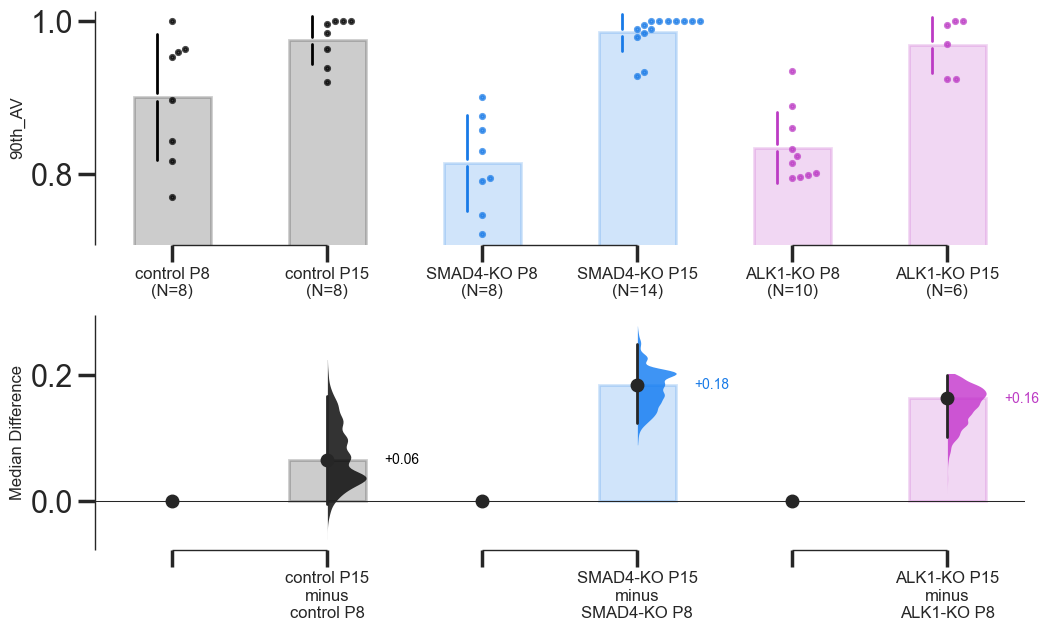

In [41]:
# --- choose the dataframe and columns correctly ---
plot_df = plot_features.copy()        # not df.copy()
x_col  = "group"                      # this holds "control P8", ...
y_col  = "90th_AV"                    # <-- change if your column is named differently

# ensure y is numeric (coerce any stray strings)
plot_df[y_col] = pd.to_numeric(plot_df[y_col], errors="coerce")

# keep only the groups you want (and in the intended order)
order = [
    "control P8","control P15",
    "SMAD4-KO P8","SMAD4-KO P15",
    "ALK1-KO P8","ALK1-KO P15",
]
plot_df = plot_df[plot_df[x_col].isin(order)].copy()
plot_df[x_col] = pd.Categorical(plot_df[x_col], categories=order, ordered=True)

# quick sanity checks (these will help if something is misspelled)
print("Groups in data:", plot_df[x_col].unique())
print("N rows per group:\n", plot_df.groupby(x_col)[y_col].size())

# --- DABEST: P15 vs P8 within each genotype (shared-control style) ---
properties_dabest = dabest.load(
    data=plot_df,
    x=x_col,
    y=y_col,
    idx=(("control P8","control P15"),
         ("SMAD4-KO P8","SMAD4-KO P15"),
         ("ALK1-KO P8","ALK1-KO P15"))
)

print(properties_dabest.median_diff)
display(properties_dabest.median_diff.results)

# optional palette (keys must match x_col labels exactly)
palette = {
    "control P8":"#000000", "control P15":"#000000",
    "SMAD4-KO P8":"#0D79F2", "SMAD4-KO P15":"#0D79F2",
    "ALK1-KO P8":"#C333CC", "ALK1-KO P15":"#C333CC",
}

fig = properties_dabest.median_diff.plot(
    custom_palette=palette,
    raw_marker_size=2.5,
    raw_alpha=0.7,
    raw_desat=0.9
)
fig.set_size_inches(12, 7)
fig.savefig(os.path.join(out_folder, "dabest_median_percentiles_P8_P15.pdf"), dpi=300, bbox_inches="tight")


DABEST v2025.03.27
                  
Good afternoon!
The current time is Thu Sep 25 16:17:46 2025.

The unpaired mean difference between control P15 and SMAD4-KO P15 is 0.0452 [95%CI -0.00328, 0.137].
The p-value of the two-sided permutation t-test is 0.135, calculated for legacy purposes only. 

The unpaired mean difference between control P15 and ALK1-KO P15 is -0.0019 [95%CI -0.0648, 0.0864].
The p-value of the two-sided permutation t-test is 0.967, calculated for legacy purposes only. 

5000 bootstrap samples were taken; the confidence interval is bias-corrected and accelerated.
Any p-value reported is the probability of observing theeffect size (or greater),
assuming the null hypothesis of zero difference is true.
For each p-value, 5000 reshuffles of the control and test labels were performed.

To get the results of all valid statistical tests, use `.mean_diff.statistical_tests`


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,...,pvalue_mann_whitney,statistic_mann_whitney,bec_difference,bec_bootstraps,bec_bca_interval_idx,bec_bca_low,bec_bca_high,bec_pct_interval_idx,bec_pct_low,bec_pct_high
0,control P15,SMAD4-KO P15,8,14,mean difference,None,0.045198,95,-0.003280,0.137446,...,0.165313,35.0,0.0,"[-0.004446218046344819, -0.017351722923813595,...","(126, 4876)",-0.087913,0.08873,"(125, 4875)",-0.08795,0.08853
1,control P15,ALK1-KO P15,8,6,mean difference,None,-0.001900,95,-0.064848,0.086449,...,0.754579,27.0,0.0,"[-0.004446218046344819, -0.017351722923813595,...","(126, 4876)",-0.087913,0.08873,"(125, 4875)",-0.08795,0.08853


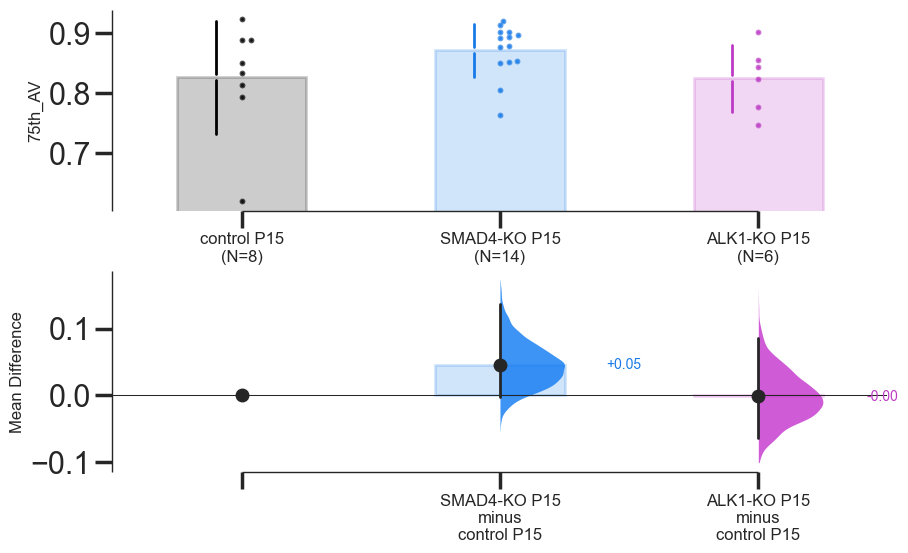

In [46]:
# reuse the same dataframe/columns you just used
# x_col = "group"
y_col = "75th_AV"   # or whatever you set earlier

# keep only the P15 groups
p15_groups = ["control P15", "SMAD4-KO P15", "ALK1-KO P15"]
plot_df_p15 = plot_df[plot_df[x_col].isin(p15_groups)].copy()
plot_df_p15[x_col] = pd.Categorical(plot_df_p15[x_col], categories=p15_groups, ordered=True)

# DABEST: shared-control with 'control P15' as reference
properties_p15 = dabest.load(
    data=plot_df_p15,
    x=x_col, y=y_col,
    idx=('control P15', 'SMAD4-KO P15', 'ALK1-KO P15')  # first = control; others vs control
)

print(properties_p15.mean_diff)
display(properties_p15.mean_diff.results)

# (optional) palette and plot
palette_p15 = {
    "control P15":"#000000",
    "SMAD4-KO P15":"#0D79F2",
    "ALK1-KO P15":"#C333CC",
}

fig = properties_p15.mean_diff.plot(
    custom_palette=palette_p15,
    raw_marker_size=1.2,
    raw_alpha=0.7,
    raw_desat=0.9,
    # raw_ylim=(...), contrast_ylim=(...)  # add if you want tighter axes
)
fig.set_size_inches(10, 6)
fig.savefig(os.path.join(out_folder, "dabest_P15_mean_75thAV_shared_control.pdf"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_folder, "dabest_P15_mean_75thAV_shared_control.png"), dpi=300, bbox_inches="tight")


DABEST v2025.03.27
                  
Good afternoon!
The current time is Thu Sep 25 16:18:46 2025.

The unpaired mean difference between control P8 and SMAD4-KO P8 is -0.0826 [95%CI -0.145, -0.0133].
The p-value of the two-sided permutation t-test is 0.035, calculated for legacy purposes only. 

The unpaired mean difference between control P8 and ALK1-KO P8 is -0.0446 [95%CI -0.0938, 0.0248].
The p-value of the two-sided permutation t-test is 0.166, calculated for legacy purposes only. 

5000 bootstrap samples were taken; the confidence interval is bias-corrected and accelerated.
Any p-value reported is the probability of observing theeffect size (or greater),
assuming the null hypothesis of zero difference is true.
For each p-value, 5000 reshuffles of the control and test labels were performed.

To get the results of all valid statistical tests, use `.mean_diff.statistical_tests`


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,...,pvalue_mann_whitney,statistic_mann_whitney,bec_difference,bec_bootstraps,bec_bca_interval_idx,bec_bca_low,bec_bca_high,bec_pct_interval_idx,bec_pct_low,bec_pct_high
0,control P8,SMAD4-KO P8,8,8,mean difference,None,-0.082554,95,-0.144883,-0.013305,...,0.020668,54.0,0.0,"[0.006982976604632318, 0.029303716673307667, 0...","(123, 4873)",-0.072755,0.073147,"(125, 4875)",-0.07268,0.073348
1,control P8,ALK1-KO P8,8,10,mean difference,None,-0.044623,95,-0.093804,0.024760,...,0.121989,58.0,0.0,"[0.006982976604632318, 0.029303716673307667, 0...","(123, 4873)",-0.072755,0.073147,"(125, 4875)",-0.07268,0.073348


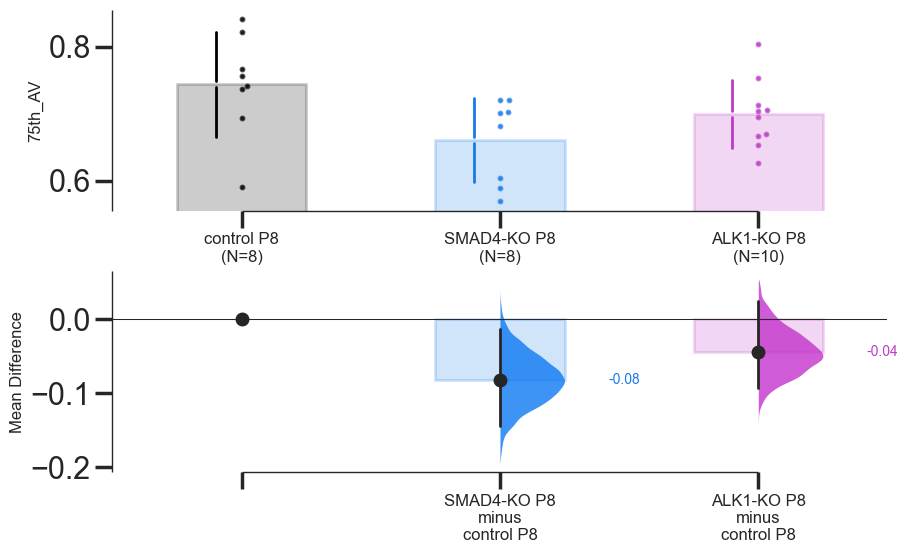

In [47]:
# reuse the same dataframe/columns you just used
# x_col = "group" 
y_col = "75th_AV"   # or whatever you set earlier

# keep only the P8 groups
p8_groups = ["control P8", "SMAD4-KO P8", "ALK1-KO P8"]
plot_df_p8 = plot_df[plot_df[x_col].isin(p8_groups)].copy()
plot_df_p8[x_col] = pd.Categorical(plot_df_p8[x_col], categories=p8_groups, ordered=True)

# DABEST: shared-control with 'control P8' as reference
properties_p8 = dabest.load(
    data=plot_df_p8,
    x=x_col, y=y_col,
    idx=('control P8', 'SMAD4-KO P8', 'ALK1-KO P8')  # first = control; others vs control
)

print(properties_p8.mean_diff)
display(properties_p8.mean_diff.results)

# (optional) palette and plot
palette_p8 = {
    "control P8":"#000000",
    "SMAD4-KO P8":"#0D79F2",
    "ALK1-KO P8":"#C333CC",
}

fig = properties_p8.mean_diff.plot(
    custom_palette=palette_p8,
    raw_marker_size=1.2,
    raw_alpha=0.7,
    raw_desat=0.9,
    # raw_ylim=(...), contrast_ylim=(...)  # add if you want tighter axes
)
fig.set_size_inches(10, 6)
fig.savefig(os.path.join(out_folder, "dabest_75thAV_mean_P8_shared_control.pdf"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_folder, "dabest_75thAV_mean_P8_shared_control.png"), dpi=300, bbox_inches="tight")
